We compare the **PMP** and the **gradient descent** algorithms.
The function that has to be approximated is
$$f(x) = \frac{1}{1 + \frac 1 d \sum_{i=1} x_i}$$

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")

# Setting

In [30]:
from ctt.bases import make_canonical_polynomials, make_fourier

d = 5
n_features = 2
basis = make_canonical_polynomials(dim=n_features)
# basis = make_fourier(n_features)
# alpha = 1e-1
# soft_relu = lambda x: alpha*jax.nn.softplus(x/alpha)
# basis = lambda x: jnp.asarray([1., jax.nn.relu(x)])
key = random.PRNGKey(42)

In [31]:
@jax.jit
def target(x: Float[Array, "d"]) -> Float[Array, "m"]:
    # val = jnp.exp(-jnp.sum(x**2)/2)
    # val = 1./(1. + jnp.mean(x))
    val = jnp.mean(x**2)
    # val = jnp.sum(jnp.sin(2*jnp.pi*x))
    # val = jnp.prod((x >= 0.)*1.)
    # val = jnp.mean(jnp.exp(x))
    return jnp.atleast_1d(val)


In [32]:
from ctt.tt import TT, tt_matvec

def lift(x: Float[Array, "d"]) -> Float[Array, "m"]:
    return jnp.hstack((0, x, x))

def retraction(x: Float[Array, "m"]) -> Float[Array, "o"]:
    return jnp.asarray((x[0],))

d_lift = jax.eval_shape(lift, jax.ShapeDtypeStruct((d,), dtype=float)).shape[0]
d_retraction = jax.eval_shape(retraction, jax.ShapeDtypeStruct((d_lift,), dtype=float)).shape[0]
bases = [basis]*(d_lift)

def _ftt(x: Float[Array, "d"], tt: TT) -> Float[Array, "d"]:
    features = [bases[i](x[i]) for i in range(x.shape[0])]  # (m,)*d
    result = tt_matvec(tt, features)  # (d, 1)
    return result[:, 0]

@jax.jit
def ctt(tts: list[TT], x: Float[Array, "d"]) -> Float[Array, "d"]:

    def _body_fn(i: int, val: Float[Array, "d"]) -> Float[Array, "d"]:
        control = jax.lax.switch(i, [lambda u=u: u for u in tts])
        return val + _ftt(val, control)
    
    x = lift(x)
    val = jax.lax.fori_loop(0, len(tts), _body_fn, x)
    val = retraction(val)
    # val = x
    # for control in tts:
    #     val = val + _ftt(val, control)
    return val

In [33]:
key, train_key, val_key = random.split(key, 3)

domain = (0., 1.)
N_train = 7000
X_train = random.uniform(key=train_key, shape=(N_train, d), minval=domain[0], maxval=domain[1])
# X_train = random.normal(key=train_key, shape=(N_train, d))
y_train = jax.vmap(target)(X_train)

N_val = 2000
X_val = random.uniform(key=val_key, shape=(N_val, d), minval=domain[0], maxval=domain[1])
# X_val = random.normal(key=val_key, shape=(N_val, d))
y_val = jax.vmap(target)(X_val)

num_steps = 10
regularization_coeff = 1e-5
radius = None
ranks = [d_lift] + [2] * (d_lift-1) + [1]

In [34]:
def dataloader(arrays: list, batch_size: int, *, key: PRNGKeyArray):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = random.permutation(key, indices)
        (key,) = random.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

# Gradient descent

In [35]:
import optax
from ctt.tt import tt_norm, TT

@jax.jit
def compute_loss(tts: list[TT],
                 x: Float[Array, "B d"],
                 y: Float[Array, "B d_o"],
                 alpha: float = 0.) -> tuple[float,float]:
    y_pred = jax.vmap(ctt, in_axes=(None, 0))(tts, x)
    # loss = jnp.mean(optax.l2_loss(y_pred, y))
    loss = jnp.mean(optax.l2_loss(y_pred, y))
    penalty = alpha*jnp.sum(jnp.asarray([tt_norm(u)**2 for u in tts]))
    return loss + penalty, loss

In [36]:
def gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                     val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                     optimizer: optax.GradientTransformation,
                     params: list[TT],
                     opt_steps: int,
                     regularization_coeff: float,
                     training_key: PRNGKeyArray,
                     batch_size: int = 64) -> tuple[list[TT], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []

    @jax.jit
    def step(tts: list[TT],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"],
             alpha: float = 0.):
        (loss, l2_error), grads = jax.value_and_grad(compute_loss, has_aux=True)(tts, x, y, alpha)
        updates, opt_state = optimizer.update(grads, opt_state, tts)
        params = optax.apply_updates(tts, updates)
        return params, opt_state, l2_error

    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error = step(params, 
                                            opt_state, 
                                            x,
                                            y,
                                            alpha=regularization_coeff)
        _, val_loss = compute_loss(params, X_val, y_val, alpha=0.)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses)

# PMP

In [37]:
from typing import Optional
from ctt.tt import tt_mul_scalar, tt_add, tt_retract

def regularization(
    xk: Float[Array, "B d_lift"], control: TT, coefficient: float
) -> float:
    return coefficient * tt_norm(control) ** 2


def terminal_cost(xT: Float[Array, "B d_lift"], y: Float[Array, "B d_o"]) -> float:
    # return jnp.mean(optax.l2_loss(xT, y))
    # return jnp.mean(optax.l2_loss(xT[:,0], y[:,0]))
    y_pred = jax.vmap(retraction)(xT)
    return jnp.mean(optax.l2_loss(y_pred, y))


def transition(xk: Float[Array, "B d_lift"], control: TT) -> Float[Array, "B d_lift"]:
    psi = jax.vmap(_ftt, in_axes=(0, None))(xk, control)
    return xk + psi


def _compute_B(
    features: list[Float[Array, "B m"]], costates: Float[Array, "B d"], ranks: list[int]
) -> TT:
    assert len(ranks) == len(features) + 1
    d = len(features)
    # compute the first component by multiplying the first factor by the costates `lambda`
    first_comp = jnp.einsum("bd,bm->dmb", costates, features[0])  # (d, m, B)

    def _factor_to_core(factor: Float[Array, "r n"]) -> Float[Array, "r n r"]:
        r, n = factor.shape
        return jax.vmap(jnp.diag, in_axes=1)(factor).transpose(2, 0, 1)

    # converting the factors to TT cores and projecting back to the TT manifold
    tt_cores = [None] * d
    tt_cores[0] = first_comp
    for mu in range(d - 1):
        core = tt_cores[mu]
        r1, m, r2 = core.shape

        # compute the SVD of the current core
        u, s, vh = jnp.linalg.svd(core.reshape(r1 * m, r2), full_matrices=False)
        new_rank = ranks[mu + 1]
        # truncate the SVD to project back to the TT manifold
        u, s, vh = u[:, :new_rank], s[:new_rank], vh[:new_rank, :]

        # replace the TT core
        tt_cores[mu] = u.reshape((r1, m, new_rank))
        # update the next core
        if mu == d - 2:
            next_core = features[-1][..., None]
        else:
            next_core = _factor_to_core(features[mu + 1])
        tt_cores[mu + 1] = jnp.einsum("ir,rkl->ikl", s[:, None] * vh, next_core)

    return tt_cores


def min_hamiltonian(
    states: Float[Array, "B d_lift"],
    costates: Float[Array, "B d_lift"],
    control: TT,
    coefficient: float,
    ranks: list[int],
    radius: Optional[float] = None,
    learning_rate: Optional[float] = None
) -> TT:
    B, d = states.shape
    features = [
        jax.vmap(bases[i])(states[:, i]) for i in range(states.shape[1])
    ]  # (B, m)*d
    tt = _compute_B(features, costates, ranks)
    if learning_rate:
        tt = tt_add(tt_mul_scalar(control, 1. - learning_rate*coefficient), tt_mul_scalar(tt, -learning_rate))
        tt = tt_retract(tt, ranks)
    else:
        tt = tt_mul_scalar(tt, -1.0 / coefficient)

    if radius:
        # project the TT to the closed ball of radius `radius`
        norm = tt_norm(tt)
        tt = jax.lax.cond(
            norm <= radius, lambda u: u, lambda u: tt_mul_scalar(u, radius / norm), tt
        )

    return tt

In [49]:
from ctt.optimizer import batch_pmp, mini_batch_pmp

def pmp(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
        val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
        params: list[TT],
        opt_steps: int,
        training_key: PRNGKeyArray,
        regularization_coeff: float,
        radius: Optional[float] = None,
        batch_size: int = 64,
        learning_rate: Optional[float] = None) -> tuple[list[TT], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset

    X_train_lifted = jax.vmap(lift)(X_train)
    optimizer = mini_batch_pmp(regularization=jax.tree_util.Partial(regularization, coefficient=regularization_coeff),
                               terminal_cost=terminal_cost,
                               transition=transition,
                               min_hamiltonian=jax.tree_util.Partial(min_hamiltonian,
                                                                     coefficient=regularization_coeff,
                                                                     ranks=ranks,
                                                                     radius=radius,
                                                                     learning_rate=learning_rate),
                                num_steps=num_steps)
    optimizer = jax.jit(optimizer)

    train_losses = []
    val_losses = []
    for i, (x_lift, x,y) in zip(range(opt_steps), dataloader((X_train_lifted, X_train, y_train), batch_size, key=training_key)):
        params = optimizer(params, x_lift, y)
        
        _, train_loss = compute_loss(params, x, y, alpha=0.)
        _, val_loss = compute_loss(params, X_val, y_val, alpha=0.)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Iter {i} | Train loss: {train_loss:.3e} | Val loss: {val_loss:.3e}")
    
    return params, (train_losses, val_losses)

# Comparison

In [43]:
from ctt.tt import tt_zeros, tt_randn

key, *control_keys = random.split(key, num_steps+1)

init_controls = [
    tt_randn(control_key, [n_features] * d_lift, ranks, cov=1.0)
    for control_key in control_keys
]
zero_init_controls = [
    tt_zeros([n_features] * d_lift, ranks)
    for _ in range(num_steps)
]
print(list(map(tt_norm, init_controls)))

[Array(3.23322381e-08, dtype=float64), Array(6.91928031e-08, dtype=float64), Array(5.6357862e-08, dtype=float64), Array(1.07978864e-07, dtype=float64), Array(8.67705262e-08, dtype=float64), Array(1.16494186e-07, dtype=float64), Array(1.08562034e-07, dtype=float64), Array(9.53603274e-08, dtype=float64), Array(1.01976987e-07, dtype=float64), Array(8.1820435e-08, dtype=float64)]


In [44]:
key, training_key = random.split(key)

In [45]:
optimizer = optax.adam(learning_rate=1e-3)
# optimizer = optax.sgd(learning_rate=1e-1)
params_gd, (train_losses_gd, val_losses_gd) = gradient_descent(train_dataset=(X_train, y_train),
                                                               val_dataset=(X_val, y_val),
                                                               optimizer=optimizer,
                                                               params=init_controls,
                                                               opt_steps=10000,
                                                               regularization_coeff=1e-4,
                                                               batch_size=64,
                                                               training_key=training_key)

Iter 0 | Loss: 7.736e-02 | Val loss: 6.316e-02
Iter 5 | Loss: 7.094e-02 | Val loss: 6.316e-02
Iter 10 | Loss: 6.562e-02 | Val loss: 6.316e-02
Iter 15 | Loss: 6.721e-02 | Val loss: 6.316e-02
Iter 20 | Loss: 6.176e-02 | Val loss: 6.316e-02
Iter 25 | Loss: 7.650e-02 | Val loss: 6.316e-02
Iter 30 | Loss: 6.317e-02 | Val loss: 6.316e-02
Iter 35 | Loss: 6.871e-02 | Val loss: 6.316e-02
Iter 40 | Loss: 5.720e-02 | Val loss: 6.316e-02
Iter 45 | Loss: 6.810e-02 | Val loss: 6.316e-02
Iter 50 | Loss: 6.686e-02 | Val loss: 6.316e-02
Iter 55 | Loss: 6.229e-02 | Val loss: 6.316e-02
Iter 60 | Loss: 5.818e-02 | Val loss: 6.316e-02
Iter 65 | Loss: 7.134e-02 | Val loss: 6.316e-02
Iter 70 | Loss: 7.047e-02 | Val loss: 6.315e-02
Iter 75 | Loss: 6.531e-02 | Val loss: 6.314e-02
Iter 80 | Loss: 6.125e-02 | Val loss: 6.312e-02
Iter 85 | Loss: 7.705e-02 | Val loss: 6.308e-02
Iter 90 | Loss: 7.173e-02 | Val loss: 6.299e-02
Iter 95 | Loss: 6.847e-02 | Val loss: 6.283e-02
Iter 100 | Loss: 6.081e-02 | Val loss: 6.2

In [46]:
y_pred = jax.vmap(ctt, in_axes=(None, 0))(params_gd, X_val)
jnp.mean(optax.l2_loss(y_pred, y_val)) / jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

Array(0.00124984, dtype=float64)

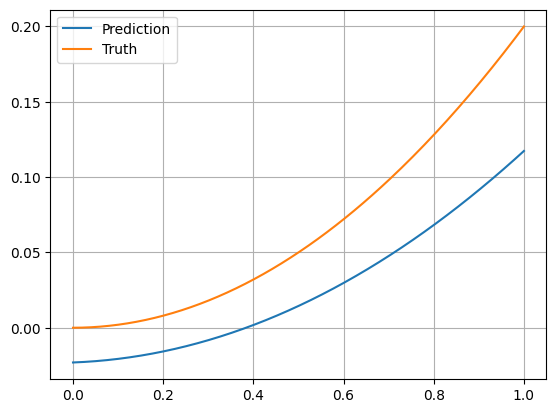

In [47]:
t = jnp.linspace(*domain, num=200)
x = jnp.concatenate((t[:,None], jnp.zeros((len(t), d-1))), axis=1)
y_pred = jax.vmap(ctt, in_axes=(None,0))(params_gd, x)
y = jax.vmap(target)(x)
plt.plot(t, y_pred, label="Prediction")
plt.plot(t, y, label="Truth")
plt.grid()
plt.legend()

IndexError: list index out of range

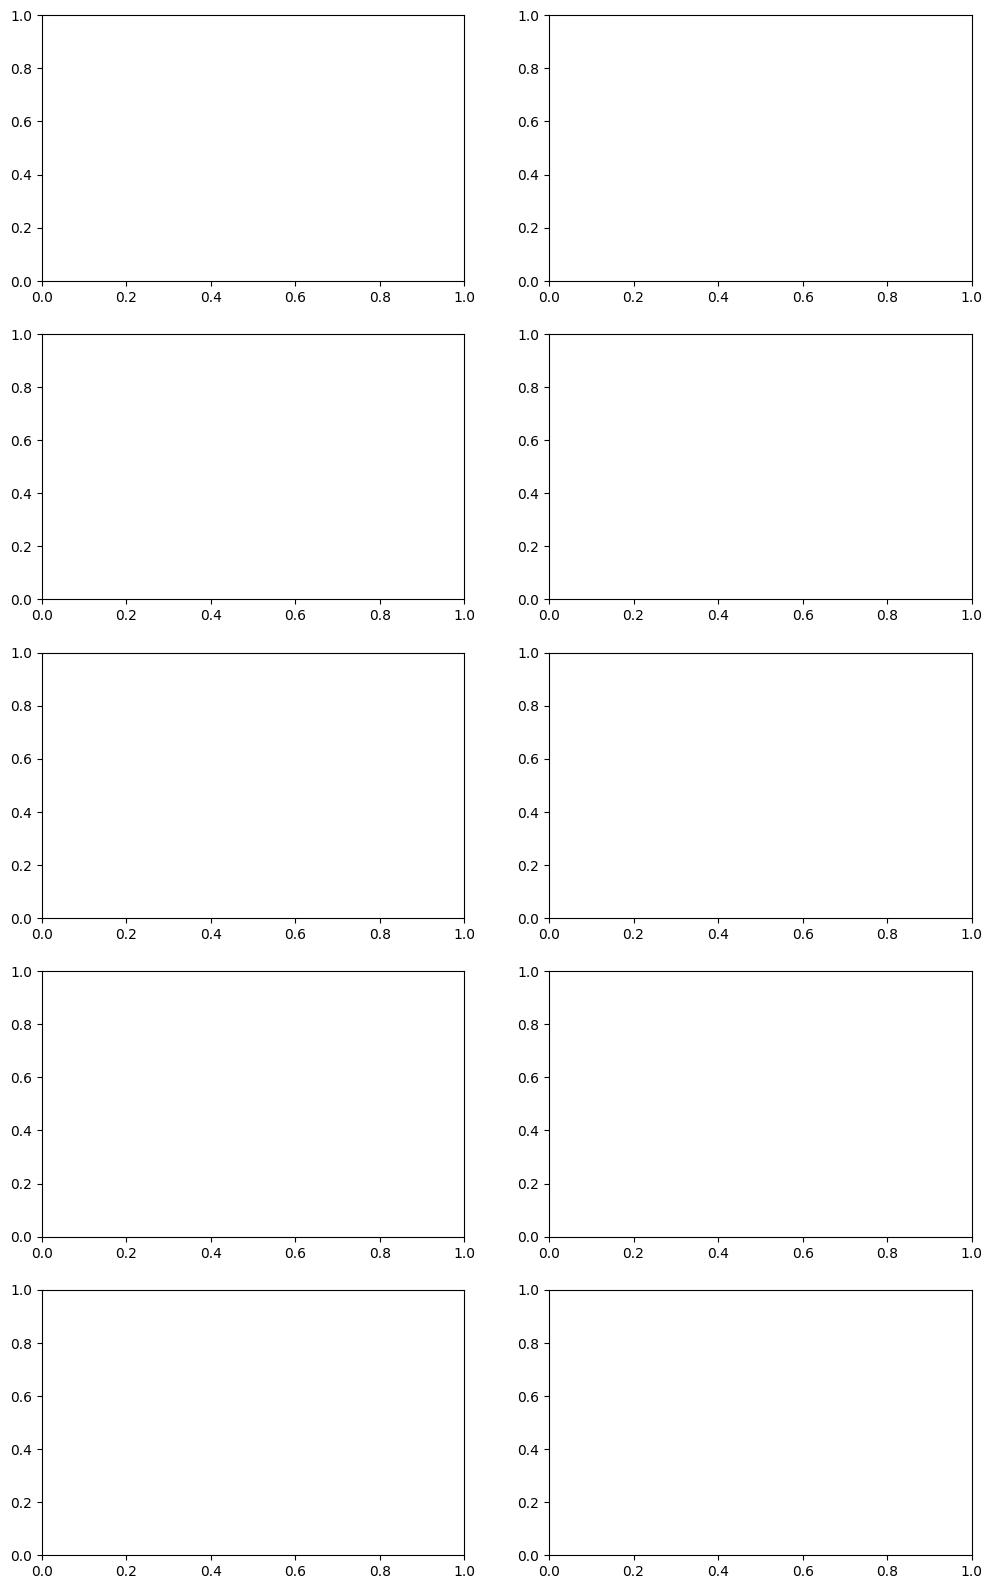

In [17]:
import numpy as np

nrows = int(np.ceil(num_steps/2))
fig, axes = plt.subplots(nrows=nrows + int(num_steps==1), ncols=2, figsize=(12, 4*nrows))

t = jnp.linspace(*domain, num=10)
x, y = jnp.meshgrid(t, t)
points = jnp.vstack((x.ravel(), y.ravel())).T

for i, (control, ax) in enumerate(zip(params_gd, axes.flatten())):
    output = points + jax.vmap(_ftt, in_axes=(0, None))(points, control)
    output = output.reshape(x.shape + (2,))
    output = np.asarray(output)
    strm = ax.streamplot(np.asarray(x), np.asarray(y), output[..., 0], output[..., 1],
                       density=1.4,
                       linewidth=None,
                       color=np.linalg.norm(output, axis=-1),
                       cmap="viridis")
    fig.colorbar(strm.lines)
    ax.set_title(f"Layer {i+1}")

In [53]:
params_pmp, (train_losses_pmp, val_losses_pmp) = pmp(train_dataset=(X_train, y_train),
                                                     val_dataset=(X_val, y_val),
                                                     params=init_controls,
                                                     opt_steps=10000,
                                                     regularization_coeff=1e-4,
                                                     radius=None,
                                                     learning_rate=7e-3,
                                                     training_key=training_key,
                                                     batch_size=64)

Iter 0 | Train loss: 7.469e-02 | Val loss: 6.123e-02
Iter 1 | Train loss: 6.665e-02 | Val loss: 5.973e-02
Iter 2 | Train loss: 6.367e-02 | Val loss: 5.822e-02
Iter 3 | Train loss: 6.480e-02 | Val loss: 5.661e-02
Iter 4 | Train loss: 5.825e-02 | Val loss: 5.532e-02
Iter 5 | Train loss: 6.030e-02 | Val loss: 5.392e-02
Iter 6 | Train loss: 5.709e-02 | Val loss: 5.267e-02
Iter 7 | Train loss: 4.631e-02 | Val loss: 5.167e-02
Iter 8 | Train loss: 4.919e-02 | Val loss: 5.065e-02
Iter 9 | Train loss: 3.982e-02 | Val loss: 4.984e-02
Iter 10 | Train loss: 5.113e-02 | Val loss: 4.876e-02
Iter 11 | Train loss: 5.090e-02 | Val loss: 4.764e-02
Iter 12 | Train loss: 4.295e-02 | Val loss: 4.671e-02
Iter 13 | Train loss: 4.180e-02 | Val loss: 4.576e-02
Iter 14 | Train loss: 4.721e-02 | Val loss: 4.473e-02
Iter 15 | Train loss: 4.539e-02 | Val loss: 4.369e-02
Iter 16 | Train loss: 4.795e-02 | Val loss: 4.260e-02
Iter 17 | Train loss: 4.491e-02 | Val loss: 4.162e-02
Iter 18 | Train loss: 3.779e-02 | Val 

KeyboardInterrupt: 

Text(0, 0.5, 'Error')

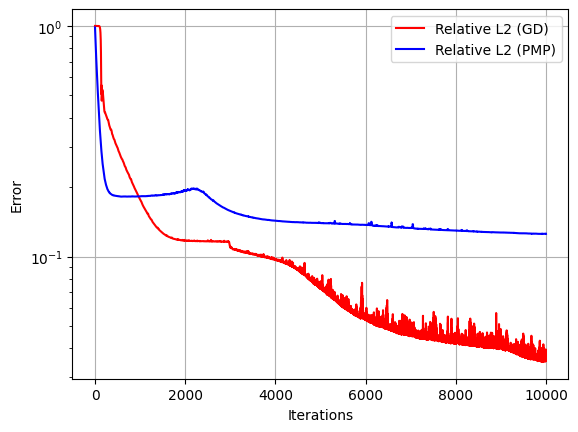

In [51]:
fig, ax = plt.subplots()

y_val_norm = jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

# plot GD losses
val_losses_gd = jnp.asarray(val_losses_gd)

ax.semilogy(jnp.arange(len(val_losses_gd)), jnp.sqrt(val_losses_gd/y_val_norm), label="Relative L2 (GD)", color="red")
# ax.semilogy(jnp.arange(len(val_losses_gd)), jnp.sqrt(val_losses_gd), label="Absolute L2", color="red", linestyle="dashed")

# plot PMP losses
val_losses_pmp = jnp.asarray(val_losses_pmp)

ax.semilogy(jnp.arange(len(val_losses_pmp)), jnp.sqrt(val_losses_pmp/y_val_norm), label="Relative L2 (PMP)", color="blue")
# ax.semilogy(jnp.arange(len(val_losses_pmp)), jnp.sqrt(val_losses_pmp), label="Absolute L2", color="blue", linestyle="dashed")

ax.grid()
ax.legend()
ax.set_xlabel("Iterations")
ax.set_ylabel("Error")